# Retrieval-Augmented Generation: Vector Search and Approximate Nearest Neighbors

# Introduction: Embeddings and Semantic Search in RAG

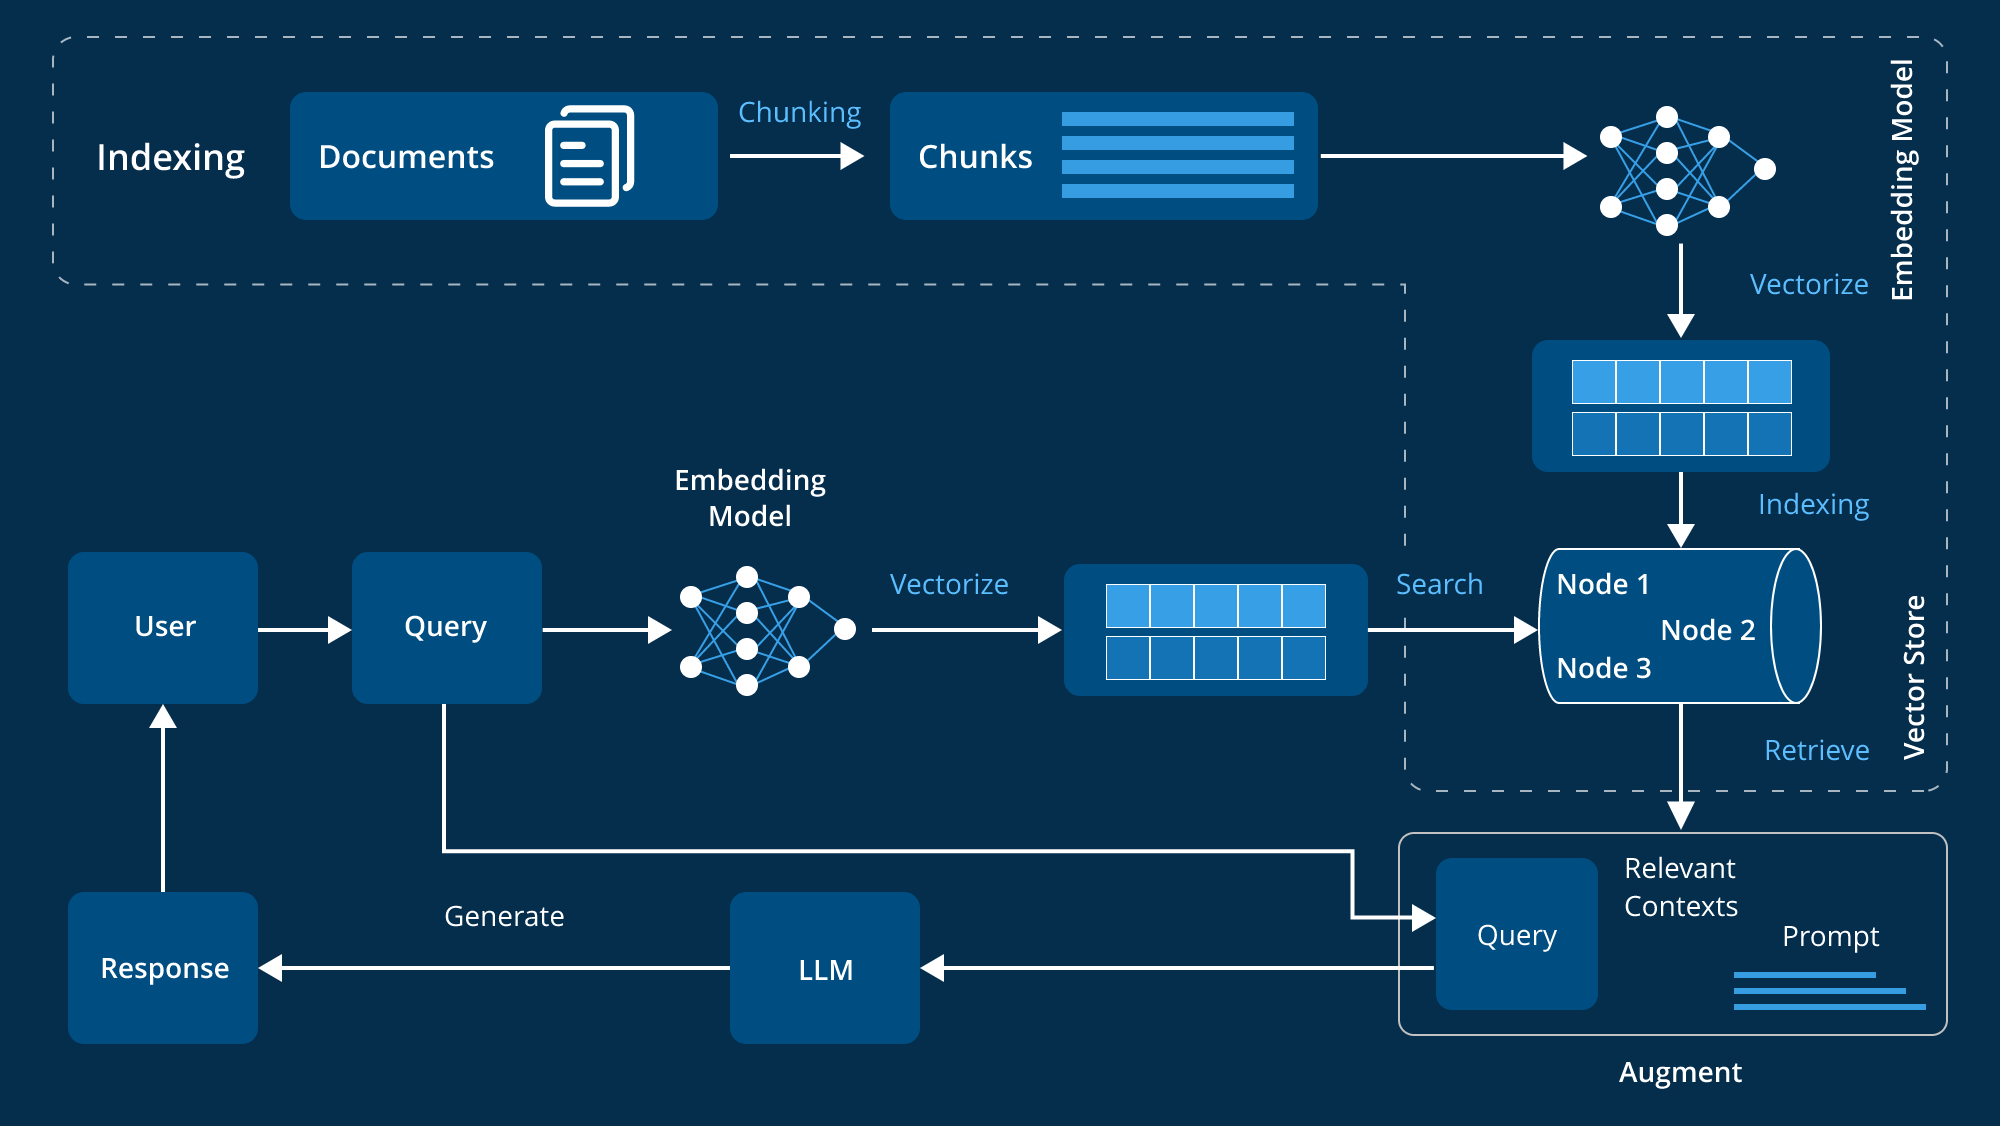

Retrieval-Augmented Generation (RAG) pipelines combine large language models with an external knowledge store, enabling LLMs to fetch relevant information on the fly ([RAG 101: Demystifying Retrieval-Augmented Generation Pipelines | NVIDIA Technical Blog](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/#:~:text=When%20a%20user%20submits%20a,data%20to%20craft%20appropriate%20responses)). At the core of this process is **semantic search** over a knowledge base of documents represented as **embeddings**. An *embedding* is a dense vector representation of data (text, images, etc.), typically in a high-dimensional space ([Embeddings, Vector Databases, and Semantic Search: A Comprehensive Guide - DEV Community](https://dev.to/imsushant12/embeddings-vector-databases-and-semantic-search-a-comprehensive-guide-2j01#:~:text=Embeddings%20are%20dense%20vector%20representations,semantic%20essence%20of%20the%20data)). These vectors are learned such that they capture the *semantic essence* or meaning of the data: points that are semantically similar will lie close together in the vector space, while dissimilar points will be far apart. In other words, the embedding space acts like a "semantic map" of the content.

**Semantic search** leverages these embeddings to find relevant information by **similarity of meaning** rather than exact keyword matching. Unlike lexical search (e.g. classic keyword or BM25 search) which matches literal terms, semantic search retrieves results that align with the *intent* or context of a query. For example, a query for "VTOL aircraft" might retrieve documents about "vertical takeoff and landing airplanes" even if the exact acronym isn't present, because the embeddings of those texts would be close in vector space. This capability is crucial in RAG: a user’s query is converted to an embedding, and the system finds the nearest neighbor embeddings in a vector database to fetch content that the LLM can use to answer the question ([RAG 101: Demystifying Retrieval-Augmented Generation Pipelines | NVIDIA Technical Blog](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/#:~:text=When%20a%20user%20submits%20a,data%20to%20craft%20appropriate%20responses)). 

Modern LLM-based applications often deal with **unstructured data** (documents, articles, etc.) that can’t be indexed reliably by keywords alone ([A quick introduction to vector search - Elasticsearch Labs](https://www.elastic.co/search-labs/blog/introduction-to-vector-search#:~:text=However%2C%20when%20you%20are%20tasked,mean%3F%20Very%20simply%2C%20the%20meaning)). Embeddings bridge this gap by transforming unstructured text into **high-dimensional vectors** where each dimension encodes some latent feature of the text. For instance, an embedding might implicitly encode concepts like topic, tone, or specific entities. Two different phrases about the same concept will map to nearby points in this space even if they share few common words. A famous illustration of embedding semantics is the analogy: *king – man + woman ≈ queen*, showing that vector arithmetic on word embeddings can capture semantic relationships.

In an RAG pipeline, after documents are encoded as embeddings and stored in a **vector store** (a specialized database for vectors), query-time retrieval is done by finding the *nearest neighbor* vectors to the query’s embedding. The retrieved texts (those with vectors most similar to the query vector) are then fed into the LLM to generate a context-informed answer. This **vector similarity search** is typically based on distance metrics like cosine similarity or Euclidean distance between the query vector and candidate vectors. A key challenge here is performance: the dataset of embeddings can be very large (thousands to millions or more), and a naive brute-force search comparing the query to every vector would be too slow to serve results in real time. Exhaustive search is $O(N)$ in the number of vectors, which becomes impractical as *N* grows (imagine scanning billions of vectors for each query).

**Approximate Nearest Neighbor (ANN) search** addresses this challenge by trading a tiny bit of accuracy for massive gains in speed. The idea is to use clever data structures and algorithms to drastically narrow down the search space so that only a small portion of the vectors are examined, ideally the ones most likely to be similar to the query. ANN algorithms organize vectors using structures like clusters, spatial trees, hash tables, or proximity graphs, and they **focus the search on the regions** of the vector space most relevant to the query. This yields **sub-linear** query times on average, meaning we can search millions of embeddings in milliseconds with high recall (finding nearest neighbors with high probability, though not *guaranteed* 100% like brute-force) . In practice, these methods make RAG pipelines feasible by enabling fast semantic lookup over large knowledge bases.


Before diving into specific ANN techniques, let’s motivate *why* vector search (and thus ANN algorithms) is so important in RAG:

- **Semantic matching:** RAG relies on retrieving by meaning. Keywords alone can fail when queries use different wording from documents. Vector search can surface relevant information even when exact words differ, thanks to embeddings capturing synonyms and context. This greatly improves the coverage of relevant knowledge for the LLM.
- **Scale of data:** Enterprises may embed entire document repositories, wikis, or even web-scale data into vectors ([RAG 101: Demystifying Retrieval-Augmented Generation Pipelines | NVIDIA Technical Blog](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/#:~:text=,query%20an%20internal%20search%20engine)). Searching these by brute force would be too slow for interactive use. ANN indexes make it efficient to retrieve from massive collections in real-time.
- **Accuracy vs. speed trade-off:** RAG needs high recall (don’t miss the relevant facts) but also low latency. ANN algorithms allow tuning this trade-off – e.g., search a bit more of the space for higher recall, or less for faster queries. The slight chance of missing the absolute nearest vector is acceptable if we can retrieve a near-enough document that still answers the query.
- **Combating lexical gaps:** Especially for technical or factual queries, a purely dense (embedding) search might overlook documents with an exact keyword (like a specific error code or name). We will later discuss how combining vector search with traditional keyword search (so-called *hybrid search*) yields the best of both worlds.

# ANN Algorithms for Vector Search

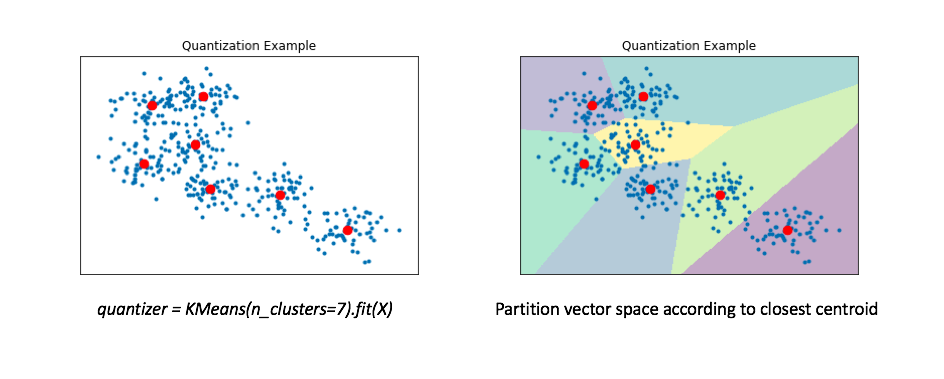

A variety of ANN algorithms have been developed to accelerate nearest neighbor search in high-dimensional spaces. We will focus on three prominent approaches used in vector search systems today:

- **Inverted File Index (IVF)** – a clustering-based partitioning of the vector space.
- **Hierarchical Navigable Small World (HNSW)** – a graph-based approach leveraging the “small world” phenomenon.
- **Locality-Sensitive Hashing (LSH)** – a hashing technique that preserves similarity.

Each of these takes a different strategy to shrink the search problem, and each has its own theory and trade-offs. It’s useful to categorize them broadly:

- *Quantization/Partitioning methods* (like IVF) break the space into regions (cells) and only search a few relevant regions for each query.
- *Graph-based methods* (like HNSW) build connectivity between points such that a search can hop from point to point and quickly converge to the neighborhood of the query.
- *Hash-based methods* (like LSH) compute signatures for vectors so that similar vectors share signatures and can be looked up via hash tables.

Ultimately, all aim to avoid brute-forcing through all points. Below we discuss each in depth, including how they work and some key formulas and results.

## Inverted File Index (IVF)

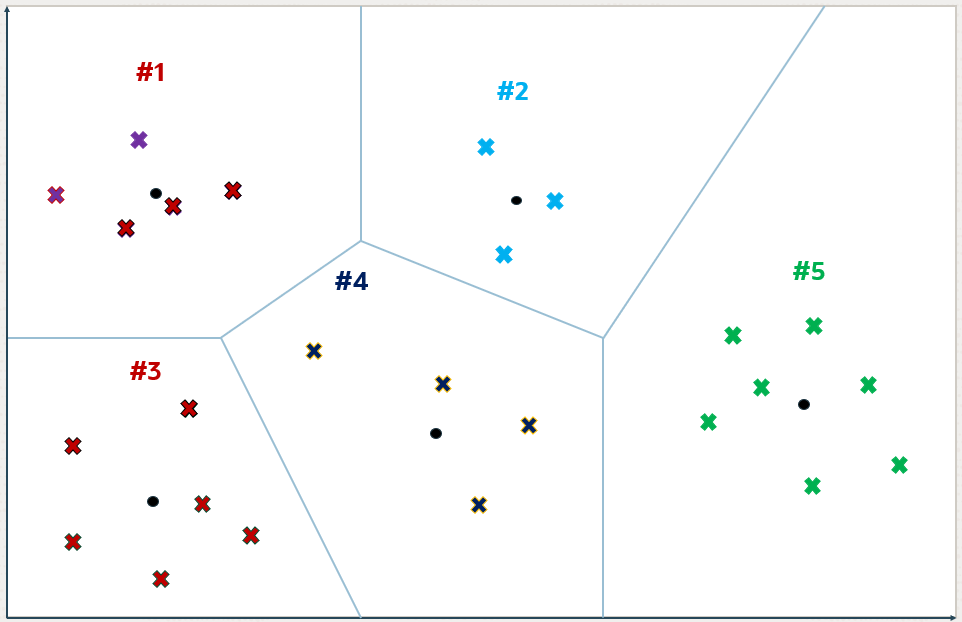

The **Inverted File Index (IVF)** is an ANN approach that **partitions the vector space into clusters** and restricts search to only the most relevant cluster(s) for a query. The idea is analogous to an inverted index in text retrieval (hence the name): rather than scanning all vectors, we **pre-group vectors by similarity** (via clustering), and at query time jump directly to the group most likely to contain the nearest neighbors.

**How IVF works:**

- **Clustering (indexing phase):** We choose a number of clusters *K* (often called `nlist` in Faiss terminology). Using a clustering algorithm (usually *k*-means), the entire dataset of vectors is partitioned into $K$ clusters. Each cluster has a centroid (the center of mass). Every vector in the dataset is assigned to its nearest centroid. Think of this as dividing the space into Voronoi cells around these centroids ([Vector databases (3): Not all indexes are created equal • The Data Quarry](https://thedataquarry.com/blog/vector-db-3#:~:text=Inverted%20file%20index%20,search%20only%20within%20that%20cell)). The index stores, for each cluster (often called a *cell*), the list of vectors (or their ids) belonging to that cluster.
- **Search (query phase):** Given a query vector $q$, we **find the nearest centroid** (or a few nearest centroids) to $q$. This can be done quickly by comparing $q$ to all $K$ centroids (since $K$ is much smaller than the total number of vectors *N*). Suppose the closest centroid is $C_j$. We then **search only within that cluster** $C_j$ for the nearest neighbors to $q$. In other words, we examine the vectors whose pre-assigned cluster is $C_j$ and compute their distances to $q$, returning the top-$k$ nearest ones from that subset.

By focusing on one cluster out of $K$, we cut down work by roughly a factor of $K$. For example, if $K=256$, we search ~0.4% of the data. In practice we often search not just one cluster, but the top few nearest clusters to improve recall (there is a parameter `nprobe` = number of clusters to probe). Searching more clusters increases the chance of finding the true nearest neighbor (in case $q$ lies near a cluster boundary), at the cost of more comparisons. This provides a nice **tunable trade-off** between accuracy and speed.

**Theoretical perspective:** The clustering introduces a quantization. Each vector $x$ in the dataset is approximated by its cluster centroid $c(x)$. At query time, we assume the nearest neighbor lies in the same cell as $q$’s nearest centroid. This isn’t guaranteed, but if clusters are reasonably tight, it’s likely. Formally, if $x^*$ is the true nearest neighbor of $q$, we hope that $c(x^*)$ is among $q$’s closest centroids. If not, we might miss $x^*$ unless we probe multiple cells.

One way to quantify error: the distance between $q$ and any vector $x$ can be decomposed as 

$$\|q - x\| \le \|q - c_i\| + \|x - c_i\|,$$ 

for $c_i$ the centroid of $x$’s cluster (triangle inequality). IVF's accuracy loss comes from the case where $q$’s nearest centroid is not the centroid of its actual NN $x^*$. To mitigate this, `nprobe` > 1 can be used to search neighboring cells of $q$. In practice, one might pick `nprobe` such that a certain fraction of the dataset is scanned (e.g. 5% of vectors) to balance recall and speed.

**Memory and build time:** Building an IVF index requires clustering the data (which can be expensive for very large datasets, though it can be done offline). The index storage includes the cluster centroids plus the assignment of each vector to a cluster (an "inverted list" of vector IDs per cluster). This is generally quite memory-efficient. Searching involves checking $K$ centroids (which is negligible if $K \ll N$) and then scanning one or a few cluster lists. If clusters are balanced, each contains ~N/K vectors on average. So search time complexity is roughly $O(K + N/K)$ for 1 cluster (and $O(K + (n_{\text{probe}}\cdot N/K))$ for multiple clusters). Choosing $K$ on the order of $\sqrt{N}$ often makes search $O(\sqrt{N})$, a significant speedup over $O(N)$ linear scan.

**References and usage:** The idea of inverted index for vectors has roots in vision and multimedia retrieval (e.g., Sivic & Zisserman’s “Video Google” 2003 used an inverted index on visual features). Jégou *et al.* (2011) introduced product quantization, greatly enhancing the practicality of such indexes. Today, IVF forms the backbone of many ANN systems. Faiss, for example, implements `IndexIVFFlat` (IVF with raw vectors) and `IndexIVFPQ` (IVF + PQ) among others, allowing users to customize `nlist` and `nprobe` . An IVF index might be denoted as *IVF*$_{nlist}$*,* where *nlist* is number of clusters; and if PQ is used, something like *IVF*$_{nlist}$*-PQ$m$ (where $m$ is number of subquantized blocks). 

**Pros:** IVF scales to very large databases. It allows flexible trade-offs: more clusters = finer partition (faster search but more index build cost), more probes = higher recall. It also parallelizes well (each cluster search is independent) and can be GPU-accelerated (Faiss exploits this heavily ([[1702.08734] Billion-scale similarity search with GPUs - arXiv](https://arxiv.org/abs/1702.08734#:~:text=This%20paper%20tackles%20the%20problem,approaches%20are%20bottlenecked%20by%20algorithms))). 

**Cons:** The recall depends on the data distribution and clustering quality. If a nearest neighbor falls in an unexpected cluster, IVF might miss it unless sufficiently many clusters are probed. Also, choosing good hyperparameters (cluster count, codebook sizes) might require tuning per dataset. The clustering step can be expensive for huge data (though there are approximate ways to cluster or one can use a subset to train centroids). Nevertheless, IVF is a foundational ANN approach for vector search – it’s conceptually simple and effective.

*Formula recap:* If $N$ vectors are partitioned into $K$ clusters, and we probe $L$ clusters for each query (with $L \ll K \ll N$), the search cost is roughly $O(K + L \cdot \frac{N}{K})$. Setting $K \approx N^{1/2}$ yields about $O(2\sqrt{N})$ operations, a drastic improvement over $N$. This comes with an empirical recall that grows as $L$ increases. One can show that if cluster assignments are good, the probability of a query’s true NN being in the top $L$ closest clusters is high for moderate $L$.

## Hierarchical Navigable Small World (HNSW)

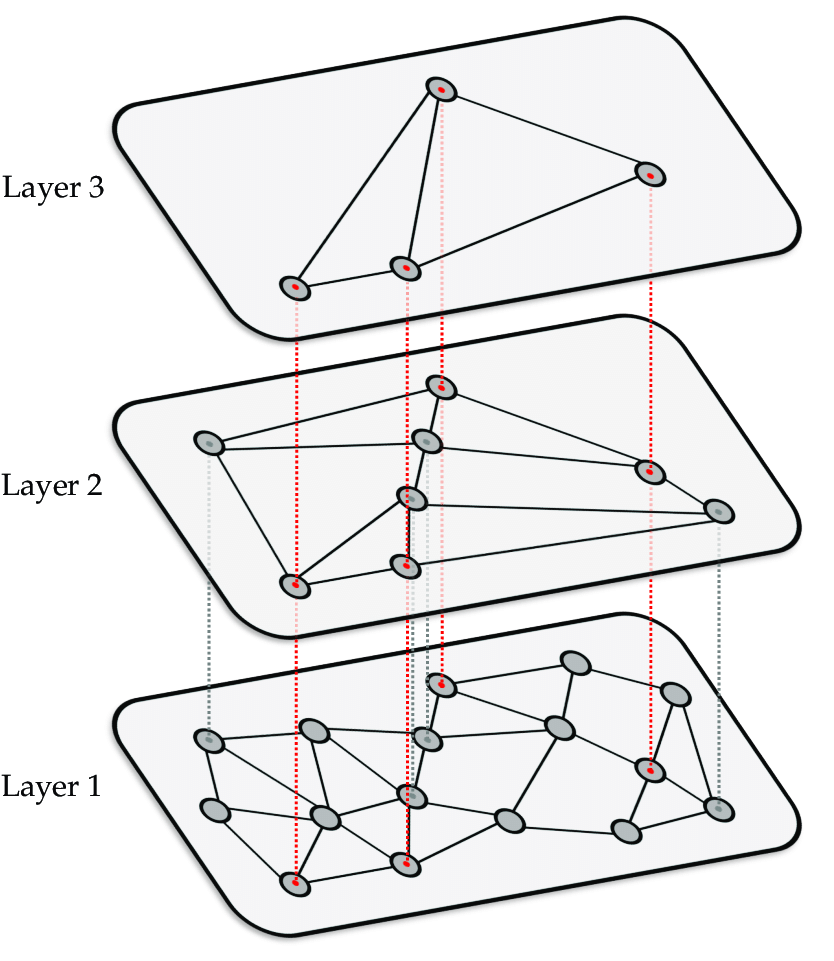

The **HNSW algorithm** is a graph-based ANN approach that has become one of the state-of-the-art methods for fast and accurate nearest neighbor search. “HNSW” stands for **Hierarchical Navigable Small World** graphs. It builds a layered graph structure that enables very efficient search by exploiting the properties of *small-world networks* (graphs where most nodes are not directly neighbors, but any node can be reached from any other via a few hops).

**Structure of HNSW:** The index is essentially a series of graphs $G_0, G_1, ..., G_{L_{\max}}$. The bottom layer $G_0$ contains all data points as nodes, with edges connecting each point to its nearest neighbors (according to some heuristic). This bottom layer is a proximity graph (similar to earlier *Navigable Small World (NSW)* graphs or *Delaunay graphs*). Each higher layer $G_{\ell}$ ($\ell > 0$) contains a *subset* of the points (fewer points as $\ell$ increases), and similarly connects those points in a graph. The highest layer $G_{L_{\max}}$ might have just a handful of nodes (or even one node). Importantly, every node that appears in layer $\ell$ also appears in all layers below it (so layers are nested subsets). Thus, layer 0 has all points, layer 1 maybe 1/(*c*) of points, layer 2 1/(*c*²) of points, etc., forming a hierarchy.

**Random level assignment:** How do we decide which points go to which layer? HNSW assigns each point an integer level $\ell_{\text{max}}(point)$ drawn from a *decreasing probability distribution*. For example, each point might start at level 0 and get promoted to level 1 with probability *p*, to level 2 with probability *p^2*, etc., so the chance of being in the top layer decays exponentially ([[1603.09320] Efficient and robust approximate nearest neighbor search using Hierarchical Navigable Small World graphs](https://arxiv.org/abs/1603.09320#:~:text=maximum%20layer%20in%20which%20an,evaluation%20has%20demonstrated%20that%20the)). This is analogous to how skip lists work: few points get very high levels, most get low levels. In fact, HNSW’s probabilistic layering yields on average $O(\log N)$ layers.

**Graph connectivity:** At each layer, each point is connected to some of the points that are closest to it (HNSW uses an algorithm to add edges such that each node has up to *M* neighbors, where *M* is a tuning parameter controlling graph density). There is also an *entry point* into the graph, usually the node with highest level (or one of them), which serves as a starting place for searches.

**Search in HNSW:** To find the nearest neighbors of a query vector $q$:
1. Start at the top layer $L_{\max}$, with the entry point node (some point in that layer).
2. From the current node, greedily traverse the graph: at each step, go to the neighbor of the current node which is *closest* to $q$ (in vector distance) *if* it is closer than the current node. Keep doing this until no neighbor is closer to $q$ than the current node – this means we have reached a local minimum on that layer.
3. Use the position found in layer $\ell$ as the starting point for search in the *next layer down* ($\ell-1$). Then perform a similar greedy neighbor walk in that layer’s graph until stuck.
4. Continue this refinement down layer by layer until you reach layer 0. In the bottom layer, to get the final $k$ nearest neighbors, HNSW actually uses a bounded DFS or heuristic search (not just greedy) to ensure it explores enough of the neighborhood. Typically it maintains a candidate max-heap of points to visit and stops when the closest candidates are finalized. This often yields very high recall with only examining a small fraction of points.

The key intuition is: the higher layers give a coarse global navigation – because edges in top layers connect very *distant* points (the graph is “small world”: even a far-apart node might have a shortcut edge). So in upper layers, the search hops quickly across the space. As we descend, layers have more points and shorter-range connections, so we refine the search locally. By layer 0, we start already quite close to the query’s nearest neighbor region, so only a local neighborhood needs exploring. This multiscale approach yields **logarithmic search complexity** on average, which is excellent.

**Complexity and parameters:** HNSW has a few parameters, mainly *M* (the maximum number of neighbors per node in the graph) and *ef* (the size of the candidate list during search; *ef* controls the recall-speed tradeoff). The **time complexity** of search is empirically about $O(M \cdot \log N)$. In practice HNSW can achieve recall > 0.99 while visiting only a few tens of points out of a million, by tuning *ef*. The **space complexity** is $O(N \cdot M)$ because we store up to *M* edges for each of N points (plus the points themselves). Typically M is 8, 16, 32, etc., so space is a few times N. This is more memory overhead than IVF (which is roughly linear in N with a small factor), but still quite reasonable.

**Why "Small World":** The term comes from graph theory – small-world graphs have short average path lengths. HNSW ensures any point can reach any other via a few hops through high-level connections, making the search efficient (like how in social networks you can reach strangers through a short chain of acquaintances).

**Quality and performance:** HNSW is known for *high recall and high speed*. It often outperforms other methods on high-dimensional data in practice. When it was introduced (Malkov & Yashunin, 2018), it achieved state-of-the-art on many ANN benchmark datasets, often reaching recall close to exact search with a fraction of the computations. It’s robust across various data distributions and dimensions. The trade-off is memory: storing the graph edges (and higher layer duplicates of points) can use more RAM, and building the graph is somewhat expensive ($O(N \log N)$ insertion). But these costs are acceptable for many applications given the excellent query performance.

**Formula (probabilistic layer assignment):** The HNSW paper states that the probability $P_{\text{max level} \geq L}$ is about $1/\mathsf{e}^L$ (or $1/c^L$ for some constant $c>1$). For example, if every point has a 1/√N chance to be in the top layer, the expected max layer size is ~√N, etc. This exponential decay ensures the top layer has $O(\log N)$ nodes and the number of layers is $O(\log N)$. The expected complexity of search is $O(\log N)$ because you essentially perform a near-constant amount of work per layer as you descend.

**HNSW in practice:** Many open-source vector databases and libraries have adopted HNSW as a default index due to its strong performance. For instance, **Qdrant** and **Vespa** use HNSW as their primary ANN index, as does **Faiss** (Faiss added HNSW as `IndexHNSW` for its inverted indices). Even ElasticSearch’s recent vector search uses HNSW under the hood for its “dense_vector” field type. The popularity is a testament to HNSW’s reliability. Typically, one sets M (graph degree) to ~16 or 32 and *ef* (search effort) to a value like 100 (higher *ef* yields higher recall but slower search). 

**Pros:** Extremely high recall-speed efficiency, works well in high dimensions where tree-based methods fail. Supports dynamic updates (you can add elements incrementally and the graph will adjust, although deletion is harder). 

**Cons:** Higher memory overhead (graph edges). Building the graph can be slower than some other methods (though still manageable for millions of points). Also, HNSW has several parameters which might need tuning for optimal performance on a given dataset (but defaults often work decently).

In summary, HNSW’s multi-layer neighbor graph approach provides a *navigable small-world network* of vectors, allowing a query to zoom into its nearest neighbors quickly. It’s a highlight of modern ANN research, combining elegant theory (skip list-like layering and small-world graphs) with practical efficiency.

## Locality-Sensitive Hashing (LSH)

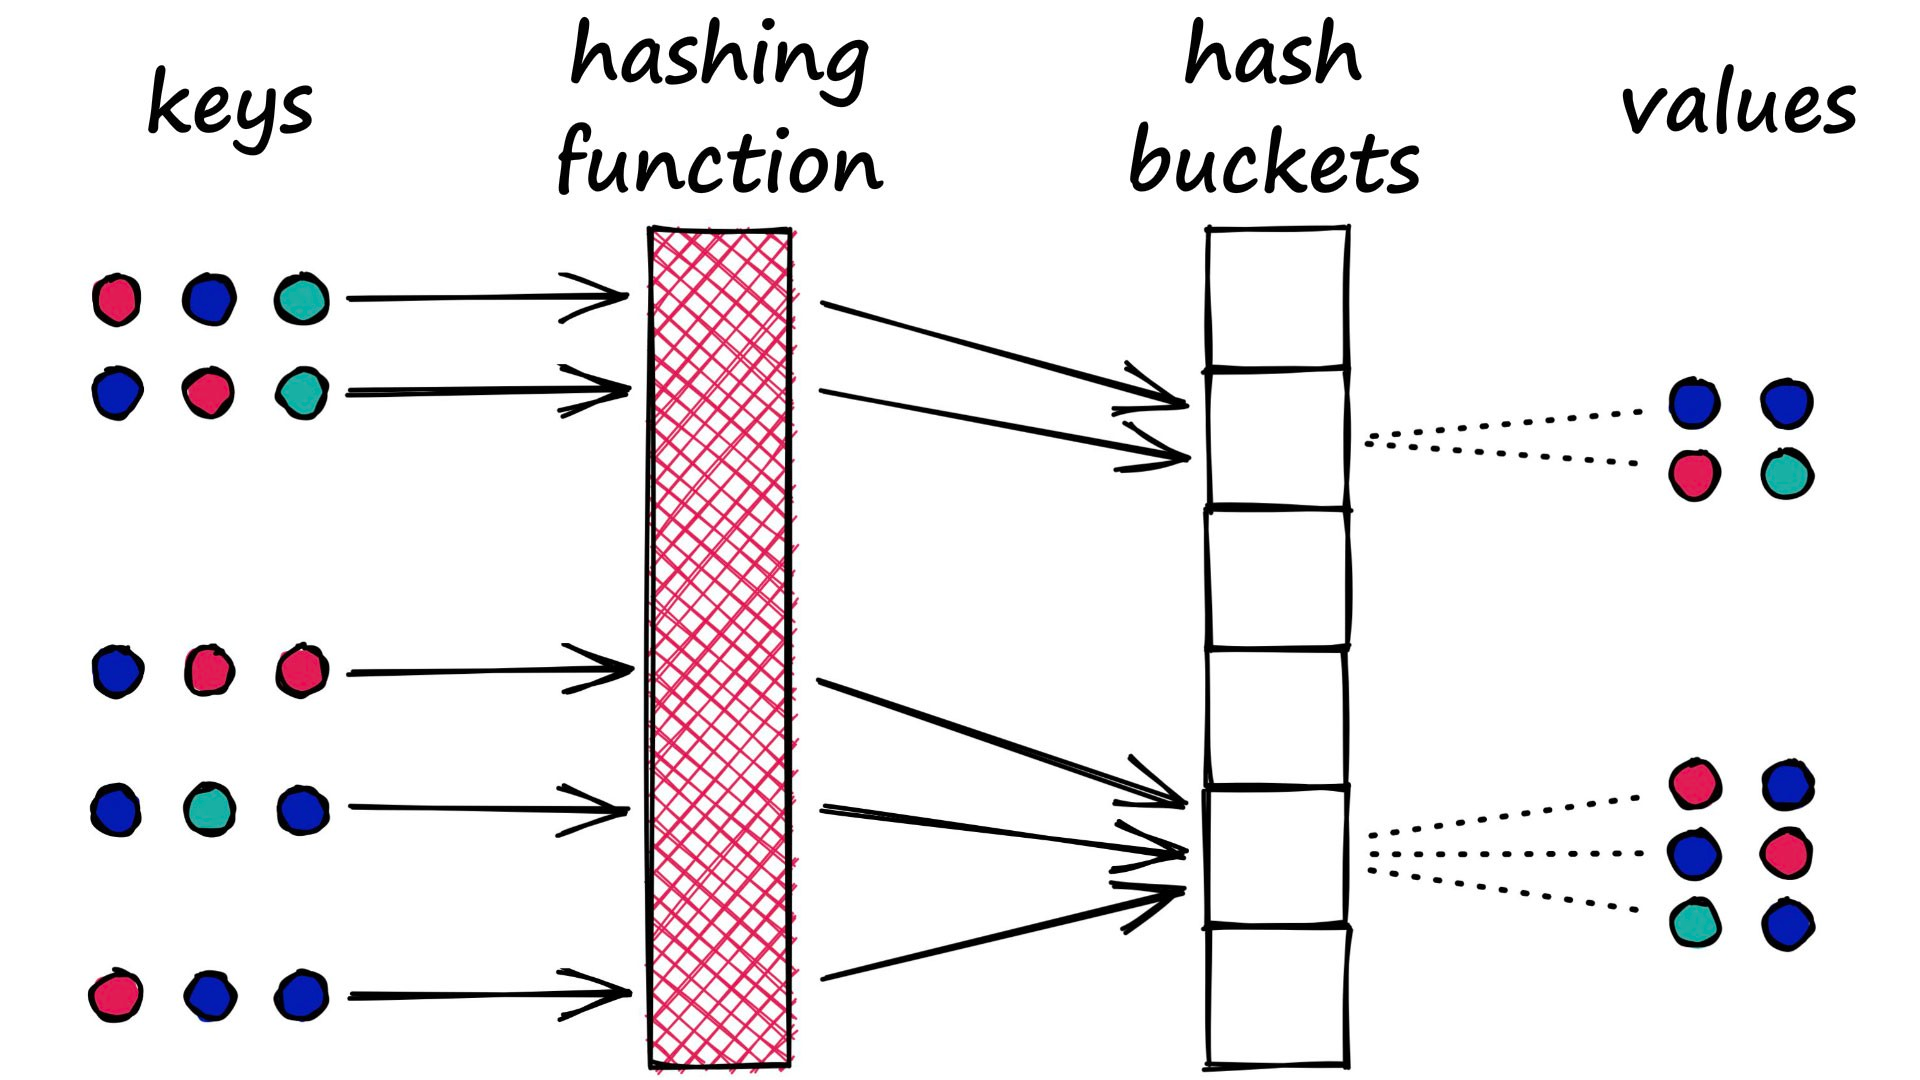

**Locality-Sensitive Hashing (LSH)** is a classic technique for ANN search that uses hashing to split vectors into buckets, such that **similar vectors are likely to fall into the same bucket** with high probability ([Locality-sensitive hashing - Wikipedia](https://en.wikipedia.org/wiki/Locality-sensitive_hashing#:~:text=In%20computer%20science%20%2C%20locality,dimensional%20versions%20while)). LSH is often described as the art of *maximizing collisions of similar items* in hash tables. By hashing points, we reduce dimensional data to discrete keys, and nearest neighbor search turns into a much faster hash table lookup problem.

**Core idea:** Design a hash function $h(\cdot)$ (or multiple hash functions) such that for any two points $x, y$:
- If $x$ and $y$ are *near* (similar) in the original space, $P[h(x) = h(y)]$ is high.
- If $x$ and $y$ are *far* (dissimilar), $P[h(x) = h(y)]$ is low.

This property is what makes the hash *locality-sensitive*. Conventional hashes (like MD5, SHA) do the opposite – they avalanche to make collisions rare. LSH deliberately wants collisions for similar data. Many families of LSH have been developed for different notions of similarity (e.g. cosine similarity, Euclidean distance, Jaccard similarity, etc.). 

**How LSH works (basic schema):**

- We choose a family of hash functions $H$ with the locality-sensitive property. For example, for cosine similarity, one common LSH is the *random hyperplane* hash: pick a random hyperplane (random normal vector) and define the hash bit as 0/1 depending on which side of the hyperplane the point lies. Using $m$ random hyperplanes gives an $m$-bit hash code. Similar vectors (small angle between them) have a high probability of yielding the same $m$-bit code ([Random Projection for Locality Sensitive Hashing | Pinecone](https://www.pinecone.io/learn/series/faiss/locality-sensitive-hashing-random-projection/#:~:text=Unlike%20most%20hashing%20functions%2C%20which,aim%20to%20maximize%20hashing%20collisions)) ([A quick introduction to vector search - Elasticsearch Labs](https://www.elastic.co/search-labs/blog/introduction-to-vector-search#:~:text=While%20conventional%20hashing%20methods%20try,clustering%20and%20nearest%20neighbor%20searches)).
- We often use not one but several hash tables to improve recall. We generate *L* independent hash functions (or hash function combinations) $g_1, g_2, ..., g_L$. Each $g_i$ could be a concatenation of a few basic hashes from $H$ (this concatenation is often called an AND-construction, to make buckets specific). So each $g_i$ maps a vector to a bucket in table $i$.
- **Indexing:** Insert each data vector into *each* of the L hash tables, under the bucket key $g_i(x)$. 
- **Query:** For a query $q$, compute its key in each table $g_i(q)$, and retrieve candidate points from all those buckets. Those candidates are then checked for actual distance to $q$ to find the true nearest neighbors among them.

The use of multiple tables (L) and possibly multiple hash functions per table (k concatenated hashes = making each bucket more selective) is to adjust the probabilities. A single hash might be too noisy (lots of false positives or false negatives). Combining k hashes (AND) makes buckets smaller (fewer points collide by chance), and using L independent hashes (OR across tables) gives multiple chances to catch a true neighbor. 

**Probability analysis:** LSH theory provides guarantees like: *given thresholds* $R$ (distance within which we consider "near") and $cR$ (distance beyond which we consider "far"), construct hashes such that:
- If $d(x,y) \le R$ (good pair), then $P[h(x)=h(y)] \ge p_1$,
- If $d(x,y) \ge cR$ (bad pair), then $P[h(x)=h(y)] \le p_2$,

with $p_1 > p_2$. By using k hashes in one concatenation, probability that a good pair still matches in that concatenation is $p_1^k$, and a bad pair matches is $p_2^k$ (much smaller if k is chosen well). Using L such concatenations (L tables) gives probability of finding at least one match for a good pair as $1 - (1 - p_1^k)^L$. We want this to be high (near 1), while the chance a bad pair ever collides in any table is $(p_2^k)^L$, which we want very low. By tuning k and L, we can make the recall as high as desired (at the cost of maybe more false positives, which just means more candidates to verify) ([](https://engineering.purdue.edu/~malcolm/yahoo/Slaney2008(LSHTutorialDraft).pdf#:~:text=not%20guarantee%20an%20exact%20answer%2C,the%20probability%20can%20be%20pushed)).

A simplified interpretation: LSH makes search **sub-linear**. In fact, under some assumptions, one can achieve query time $O(N^\rho)$ for some $\rho < 1$ and space $O(N^{1+\rho})$. For example, there are LSH schemes for Euclidean distance that achieve $\rho = 1/c^2$ for searching within a factor-$c$ nearest neighbor. The mathematics can get detailed, but the key is LSH offers theoretical guarantees on probabilities of success, which many other ANN methods lack.

**Example (Cosine LSH):** The random hyperplane method (Charikar, 2002) generates a random vector $r$ and defines $h_r(x) = \text{sign}(r \cdot x)$ (1-bit hash). For two vectors $x,y$, $P[h_r(x)=h_r(y)] = 1 - \frac{\theta(x,y)}{\pi}$, where $\theta(x,y)$ is the angle between them. If they are identical ($\theta=0$), collision prob = 1; if they are orthogonal ($\theta=90^\circ$), prob = 0.5; if opposite ($\theta=180^\circ$), prob = 0. This is an LSH for cosine similarity. Usually, we use, say, 24 such random bits and maybe L=10 tables to get good recall for nearest neighbor search in practice.

**Example (Euclidean LSH):** One popular LSH for L2 distance uses *p-stable distributions* (Datar et al. 2004): pick a random projection vector and offset, then quantize to a bin. Essentially $h(x) = \lfloor (a \cdot x + b)/w \rfloor$ for random $a$ (Gaussian) and random offset $b \in [0,w)$, which hashes points on a line. Nearby points likely land in same bin if $w$ is tuned to threshold distance $R$. This can be repeated and combined for multiple dimensions. 

**Search complexity:** Querying L hash tables and checking all points in the buckets found. If your parameters are set so that each bucket has small number of points (due to the hash randomness), then the total check is much smaller than N. Typically, one aims for each table lookup to yield, say, a few hundred candidates, so overall maybe a few thousand candidates are distance-checked, instead of N. LSH has a guarantee that for large enough N, sub-linear scaling is achieved.

**Pros:** The big draw of LSH is its **theoretical guarantees** on the probability of finding near neighbors (as a function of how “near” they are) and sub-linear query performance *with high probability*. It was one of the first approaches to break the curse-of-dimensionality barrier in theory (Indyk and Motwani’s seminal work in late 1990s). It’s conceptually simple and easy to implement with hash tables. Also, it's versatile: different LSH families exist for different metrics (cosine, Euclidean, Jaccard, etc.). 

**Cons:** LSH often requires a lot of memory because you maintain many hash tables for large datasets. The constant factors can be high, meaning to get, say, 95% recall, you might need dozens of tables or long hash keys, which store many entries. Also, when data is extremely high-dimensional but intrinsically not well-separated, LSH might need very large L to work well. In practice, newer methods like HNSW often outperform LSH in speed/recall for most scenarios. LSH might retrieve too many candidates if data clusters densely, leading to slower query times unless carefully tuned. Another issue is that LSH doesn’t adapt to data distribution (it’s *data-independent hashing*), so in some cases a data-dependent approach could build more optimal partitioning.

However, LSH still has niches and is intellectually important. It’s used in some large-scale systems (for example, early versions of Spotify’s music recommendation reportedly used LSH for audio similarity, and some approximate string/join algorithms use min-hash or sim-hash which are forms of LSH). It remains a baseline for ANN research and has inspired subsequent methods.

**Summary:** LSH creates a set of *hash buckets* where similar items collide. The algorithm is straightforward:
1. Precompute hash keys for all vectors, insert into tables.
2. Hash the query, retrieve candidates from matching bucket(s).
3. (Optional) check distances of candidates to find true nearest neighbors.
Because most of the heavy computation (assigning hashes) is done at index time, queries are fast – essentially just computing a few hashes and looking up in a dictionary ([A quick introduction to vector search - Elasticsearch Labs](https://www.elastic.co/search-labs/blog/introduction-to-vector-search#:~:text=vectors%20that%20are%20close%20together,clustering%20and%20nearest%20neighbor%20searches)). Any *missed* true neighbor is due to the probability $<1$ of collision, but we can compensate by more hashing. Thus, by “investing more computation” (more hash functions/tables), we can push the miss probability arbitrarily low ([](https://engineering.purdue.edu/~malcolm/yahoo/Slaney2008(LSHTutorialDraft).pdf#:~:text=not%20guarantee%20an%20exact%20answer%2C,the%20probability%20can%20be%20pushed)).

One can mathematically derive that to achieve a certain success probability, the number of tables L grows roughly as $N^\rho$ for some exponent $\rho$ related to the hardness of the dataset (e.g., $\rho = 1/c$ for points on a certain distribution). This sub-linear dependence is the theoretical win of LSH.

**Recap of a formula:** If $P_1$ is the collision prob for a near neighbor and $P_2$ for a far point, using $k$ hashes per table and $L$ tables, the probability of *at least one collision* for a near neighbor is $1 - (1 - P_1^k)^L$ ([Locality-sensitive hashing - Wikipedia](https://en.wikipedia.org/wiki/Locality-sensitive_hashing#:~:text=match%20at%20L489%20,P_%7B1%7D%5E%7Bk%7D%29%5E%7BL)). We want this $\approx 1$. Meanwhile, the probability a far point sneaks into any bucket is $(P_2^k)^L$, which we want $\approx 0$. These guide choosing $k, L$. For example, if $P_1=0.5$, $P_2=0.1$, and we use $k=2$ hashes per table, then one table has near collision $0.25$ and far collision $0.01$. With $L=10$ tables, near success $\approx 1-(1-0.25)^{10}=0.94$ (~94% chance to catch a near neighbor), while far false match $\approx 10 * 0.01 = 0.1$ (10% chance a far point shows up across all tables). Adjusting parameters can improve these numbers. This simple calculation shows the tuning logic of LSH.

**In practice:** There are libraries for LSH (e.g., Facebook’s *FALCONN* for Euclidean LSH, or Spotify’s *Annoy* which can be seen as a type of randomized tree-LSH hybrid). But pure LSH is less commonly used in modern vector DBs which favor HNSW or IVF. Still, understanding LSH gives insight into how *hashing* can aid ANN and it remains a part of the ANN toolkit.

## ANN Examples

In [3]:
#pip install faiss-cpu

In [1]:
import numpy as np
import faiss
import time

# dim = dimensionality of vectors
d = 128
# nb = number of database vectors; nq = number of queries
nb, nq = 100_000, 10_000

# database and query vectors (normalized for inner-product similarity)
np.random.seed(1234)
xb = np.random.random((nb, d)).astype('float32')
xb /= np.linalg.norm(xb, axis=1, keepdims=True)
xq = np.random.random((nq, d)).astype('float32')
xq /= np.linalg.norm(xq, axis=1, keepdims=True)

In [2]:
index_flat = faiss.IndexFlatIP(d)                
index_flat.add(xb)

k = 5                                           # top-5 neighbors

t0 = time.time()
D_flat, I_flat = index_flat.search(xq, k)
t_flat = time.time() - t0
print(f"FlatIP search time:  {t_flat:.3f}s")
print("Bruteforce Top 5 neighbor indices:", I_flat[0])
print("Top 5 similarity scores:", D_flat[0])

FlatIP search time:  0.646s
Bruteforce Top 5 neighbor indices: [22241 39869 41637 93474  6495]
Top 5 similarity scores: [0.8360947  0.83367383 0.83213884 0.83203816 0.83187515]


In [3]:
# Choose number of coarse centroids (nlist)
nlist = 256
quantizer = faiss.IndexFlatIP(d)                  # coarse quantizer
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

# Training
assert not index_ivf.is_trained
index_ivf.train(xb)                               
assert index_ivf.is_trained

#  Add database vectors
index_ivf.add(xb)                                 

index_ivf.nprobe = 8                             # search 8/256 lists
t0 = time.time()
D_ivf, I_ivf = index_ivf.search(xq, k)
t_ivf = time.time() - t0
print(f"IVFFlat search time: {t_ivf:.3f}s")
print("IVF Top 5 neighbor indices:", I_ivf[0])
print("Top 5 similarity scores:", D_ivf[0])

IVFFlat search time: 0.171s
IVF Top 5 neighbor indices: [39869 83354 48173 89250 68328]
Top 5 similarity scores: [0.833674   0.82643384 0.8263855  0.824743   0.8242607 ]


| **Parameter**       | **Role**                                                                                     | **Effect of increasing it**                                                         |
|---------------------|----------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------|
| **M**               | Number of bi‐directional links each new point is connected to in the graph.                  | Higher **M** → denser graph → better accuracy (recall); costs more memory & slower build. |
| **efConstruction**  | Size of the candidate list used **during index building** when inserting points.             | Higher **efConstruction** → more thorough build‐time neighbor search → better recall; costs more time & memory. |
| **efSearch**        | Size of the candidate list used **at query time** to explore the graph.                      | Higher **efSearch** → explores more candidates per query → higher recall; costs slower queries. |


In [5]:
M = 32
index_hnsw = faiss.IndexHNSWFlat(d, M, faiss.METRIC_INNER_PRODUCT)

# You can tune construction/search ef parameters:
#   efConstruction controls indexing time/accuracy
#   efSearch   controls query-time recall/speed
index_hnsw.hnsw.efConstruction = 200
index_hnsw.add(xb)

# Query
index_hnsw.hnsw.efSearch = 50
t0 = time.time()
D_hnsw, I_hnsw = index_hnsw.search(xq, k)
print(f"HNSWFlat time:{time.time() - t0:.3f}s")
print("HNSWFlat Top 5 neighbor indices:", I_hnsw[0][:5])
print("HNSWFlat Top 5 similarity scores:", D_hnsw[0][:5])

HNSWFlat time:0.504s
HNSWFlat Top 5 neighbor indices: [22241 41637 93474  6495 45244]
HNSWFlat Top 5 similarity scores: [0.8360946  0.8321389  0.83203816 0.83187497 0.83122605]


In [6]:
nbits = 128
index_lsh = faiss.IndexLSH(d, nbits)

# No training step for LSH; just add vectors
index_lsh.add(xb)

#IndexLSH returns Hamming-distance scores on the binary hashes—it’s very fast but less precise.
# Search
t0 = time.time()
D_lsh, I_lsh = index_lsh.search(xq, k)
print(f"LSH time:    {time.time() - t0:.3f}s")
print("LSH Top 5 neighbor indices:", I_lsh[0][:5])
print("LSH Top 5 similarity scores:", D_lsh[0][:5])

LSH time:    0.217s
LSH Top 5 neighbor indices: [48819 66349 77944 81453 13636]
LSH Top 5 similarity scores: [14. 14. 14. 14. 15.]


In [7]:
candidates = xb[I_lsh]                    # shape: (nq, k, d)
# expand queries to (nq, 1, d) then elementwise multiply & sum over d:
ip_scores = np.einsum('nkd,nid->nk', candidates, xq[:, None, :])

# Now for each query we sort these k IP‐scores to get the true top‐k:
top_k_idx = np.argsort(-ip_scores, axis=1)  # descending sort
# reorder both IDs and scores
I_rerank = np.take_along_axis(I_lsh, top_k_idx, axis=1)
D_rerank = np.take_along_axis(ip_scores, top_k_idx, axis=1)

print("Re‐ranked Top‐5 IDs:    ", I_rerank[0, :5])
print("Re‐ranked Top‐5 scores: ", D_rerank[0, :5])

Re‐ranked Top‐5 IDs:     [66349 77944 81453 13636 48819]
Re‐ranked Top‐5 scores:  [0.78938645 0.78464615 0.78188074 0.7730029  0.7454471 ]


# Hybrid Search: Combining Vector and Lexical Retrieval

While dense vector search is powerful, it doesn’t entirely replace classical lexical search – instead, they can complement each other. This complementary nature gives rise to **hybrid search**, which fuses semantic (vector) search with keyword (sparse) search to get the best of both worlds. The motivation for hybrid search comes from cases where **exact term matching matters** even if embeddings might overlook it. For example:

- A query contains a rare proper noun, code snippet, or specific keyword. An embedding might focus on the semantic context and miss that exact detail, whereas a keyword search would prioritize it. BM25 (a lexical scoring function) excels at boosting rare terms via IDF ([BM42: New Baseline for Hybrid Search - Qdrant](https://qdrant.tech/articles/bm42/#:~:text=That%20explains%20why%20BM25%20is,domain)).
- Conversely, a purely lexical search might miss paraphrases or conceptual matches that a dense search would catch (e.g., "influenza" vs "flu" in a query/document).
- In an enterprise setting, queries might use jargon or refer loosely to content – dense retrieval brings in relevant context, but ensuring certain keywords appear (via sparse retrieval) can filter out off-target results.

Hybrid search aims to **merge these signals**: the **semantic relevancy signal from embeddings** and the **lexical precision signal from text**. The result is typically improved relevance and recall.

**Approaches to Hybrid Search:**

1. **Score Fusion:** Run the vector search and the keyword search separately, then combine their result lists. Each document will have a vector similarity score and a lexical score (e.g., BM25). To fuse, one can:
   - **Rank fusion methods:** e.g. **Reciprocal Rank Fusion (RRF)**, which is simple and effective. RRF takes the rank positions of a document in each list and combines them (documents that rank high in both dense and sparse lists get a big boost) ([Hybrid Queries - Qdrant](https://qdrant.tech/documentation/concepts/hybrid-queries/#:~:text=Qdrant%20currently%20has%20two%20ways,the%20results%20from%20different%20queries)). For example, with two rankings, you might give a combined score = 1/(rank_dense + C) + 1/(rank_lexical + C) for some constant C. Documents that appear in both lists with good ranks score highest.
   - **Weighted sum of scores:** If both systems produce normalized scores (like a similarity and a BM25 score), one can take a weighted sum: $score = \lambda \cdot \text{sim}_{dense} + (1-\lambda) \cdot \text{score}_{BM25}$. Tuning $\lambda$ adjusts emphasis on semantic vs lexical. This requires some normalization of scales, which can be tricky.
   - **Learning to rank:** In more advanced settings, one could train a model to combine features (dense similarity, BM25, etc.) to predict relevance. But a simple fusion is often sufficient.

2. **Unified Index with Sparse & Dense Features:** Some vector databases allow storing **sparse vectors** representing the TF-IDF or BM25 weights of documents. For example, Qdrant introduced support for "sparse vectors" so that you can encode a document’s term frequencies as a high-dimensional sparse vector (dimension = vocab size or a hashing of it) ([A guide to hybrid search (using Splade) in Qdrant vector database | by Viraj Kadam | Medium](https://viraajkadam.medium.com/a-guide-to-hybrid-search-using-splade-qdrant-vector-database-a4b70e243f4a#:~:text=But%20for%20a%20application%2C%20some,both%20dense%20and%20sparse%20retrieval)) ([A guide to hybrid search (using Splade) in Qdrant vector database | by Viraj Kadam | Medium](https://viraajkadam.medium.com/a-guide-to-hybrid-search-using-splade-qdrant-vector-database-a4b70e243f4a#:~:text=search,and%20other%20similarity)). The same query can be converted into both a dense embedding and a sparse term vector. The database can then perform a combined similarity search. Essentially, the dense vector captures semantics and the sparse vector captures exact term overlap. By querying both representations, we ensure documents that either have high semantic similarity or keyword matches (or ideally both) surface to the top.

3. **Filtering + Reranking:** Another pattern is to use one method to pre-filter candidates and the other to rerank them. For instance:
   - **Lexical first, semantic second:** Use a BM25 engine (like Lucene) to get, say, top 1000 candidates containing some keywords from the query, then compute embeddings of those and rank by similarity to the query embedding. This ensures all results contain certain key terms, reducing the chance of irrelevant off-topic results that sometimes dense retrieval can return if it latches onto wrong semantics. This approach might miss some semantic matches that lacked any query terms, but it's high-precision.
   - **Semantic first, lexical second:** The opposite: retrieve by embedding similarity (many vector hits), then rerank or filter them by a lexical criterion (e.g., ensure the top ones also share at least one important keyword with the query). This could catch more semantically relevant pieces, then use lexical scoring to sort those with exact matches higher.

In practice, *hybrid search* often refers to a system that can do something like **dense + keyword in one query**. For example, ElasticSearch’s hybrid queries allow you to specify a text query and a vector query and combine the scores. Qdrant’s new Query API supports building such multi-stage retrieval pipelines on the server side. 

**Qdrant’s approach to hybrid:** Qdrant (an open-source vector DB) as of version 1.10+ enables you to directly perform hybrid search by storing both dense and sparse vectors and fusing results. You can issue a query that says "search this sparse index with these terms and this dense index with this embedding, and fuse with RRF or another method". The **motivation** is exactly as above: *"in text search, it is often useful to combine dense and sparse vectors to get the best of semantics plus the best of matching specific words."*. Qdrant implements two fusion methods: `rrf` (Reciprocal Rank Fusion) and a newer `dbsf` (Distribution-Based Score Fusion) which normalizes scores and sums them. By handling this inside the DB, Qdrant saves the developer from orchestrating two separate search systems.

**Example scenario:** Suppose we have a documentation database. A user asks: "How do I reset my S3 bucket permissions?" A dense embedding of this question will retrieve passages about "resetting AWS S3 access, bucket policies" etc. But maybe one specific guide has a code snippet with the phrase "s3:PutBucketAcl". A pure dense search might get relevant guides, but a keyword search for "S3 bucket permissions" (or "PutBucketAcl") ensures that if there's a document explicitly about S3 permissions, it will be found even if the embedding might have given equal weight to a more generic cloud permissions doc. A hybrid search could bring the explicit guide to the top by noticing the query's keywords match it strongly, while still considering semantic matches for context.

In essence, **hybrid search addresses failure modes of pure dense or pure sparse search**:
- Dense retrieval can sometimes retrieve something topically related but missing a critical detail (hallucinating relevance). If the query mentions a precise term, sparse ensures that term appears.
- Sparse retrieval can fail if query and document use different language (synonyms, paraphrases). Dense covers that.

It’s worth noting that current **state-of-the-art retrieval pipelines in research use hybrid techniques**. Recent competitions and papers often combine a BM25 retrieval with a dense retriever to boost recall. One approach (used in some systems like ColBERTER, Splade etc.) is to train models that output both a dense and sparse representation. **Splade** is a model that generates a sparse vector (in vocabulary space) from a transformer, effectively predicting important terms for the query and document. Using Splade vectors is like a learnable BM25, and combining that with dense embeddings leads to very strong results. In fact, *BM25 remains a tough baseline to beat*, so augmenting it rather than replacing it is wise.

To underscore this: *"The current state-of-the-art approach to retrieval nowadays tries to incorporate BM25 along with embeddings into a hybrid search system."*. This quote reflects how even with powerful neural models, the old keyword matching still adds value. The RAG context specifically is mentioned: with RAG, the nature of queries and documents (often shorter texts, or precise Q&A pairs) might differ from web search, but still BM25 assumptions hold partially. Hybrid search is thus very relevant for RAG-based QA systems.

**Implementing Hybrid search practically:**
- If using ElasticSearch, one can index documents with both text (for BM25) and vectors (for cosine similarity), then use a script or function score query that linearly combines the BM25 score and the cosine similarity score.
- If using Qdrant, one would create a collection with two vector slots: one for dense (embedding), one for sparse (which uses a special sparse vector type). Then one can query with `prefetch` or `with_payload` to do the combined search using the new Query API. Qdrant’s docs show an example using **Reciprocal Rank Fusion** on the results of two queries (one to the dense index, one to the sparse index).
- If using Weaviate or Pinecone, they also support hybrid queries (Weaviate allows specifying a BM25 query alongside a vector query, Pinecone has a sparse-dense fusion capability as well).

Hybrid search often significantly boosts performance on information retrieval metrics like Recall@k or NDCG, especially on datasets where some queries use rare terminology (where a purely semantic approach might falter). It is highly recommended in production QA systems to handle edge cases.

**Potential downside:** Doing two searches (dense + sparse) can be slower than one. However, since both can be independently pruned (and one can limit say to top 50 from each, then fuse), the overhead is manageable. Also, with an integrated vector DB that supports both, it's optimized internally. Another complexity is scoring normalization: combining scores from different systems (cosine similarity vs BM25) needs careful scaling or a rank-based method like RRF to avoid needing to directly compare heterogeneous scores.

# Using Qdrant

Qdrant is a production-ready vector database written in Rust, accessible via REST or client libraries (Python, etc.). It manages persistence, sharding, filtering, and provides HNSW indexing under the hood. Unlike Faiss (which is in-memory unless you save index to disk manually), Qdrant is a server one can run that stores collections of vectors with optional payload (metadata).

Typical usage:
1. Start Qdrant (via Docker or in-memory).
2. Create a collection specifying vector dimensions and type.
3. Insert (upsert) points with their vector and an ID (and any metadata).
4. Query by vector or filter + vector, etc.

pip install qdrant-client

In [2]:
from qdrant_client import QdrantClient, models

# Connect to Qdrant (assuming it's running locally on default port or use :memory: for in-process)
client = QdrantClient(":memory:")  # using in-memory Qdrant (for demo; in practice, connect to a Qdrant server)

In [3]:
d = 768

collection_name = "documents"
client.recreate_collection(
    collection_name=collection_name,
    vectors_config={
        "embedding": models.VectorParams(size=d, distance=models.Distance.COSINE)
    }
)

/tmp/ipykernel_2503298/4025591358.py:4: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


True

In [5]:
import random
import numpy as np

from tqdm.autonotebook import tqdm

points = []
for idx in tqdm(range(10_000)):
    vec = np.random.random(d).tolist()
    payload = {"doc_text": f"Document number {idx}"}
    points.append(models.PointStruct(id=idx, vector={"embedding": vec}, payload=payload))
client.upsert(collection_name=collection_name, points=points)
print("Inserted 10k points.")

  0%|          | 0/10000 [00:00<?, ?it/s]

Inserted 10k points.


In [10]:
query_vec = np.random.random(d).tolist()
hits = client.search(
    collection_name=collection_name,
    query_vector=("embedding", query_vec),
    limit=10,
    with_payload=True
)
for hit in hits:
    print(f"Found id={hit.id} with score={hit.score:.3f}, payload={hit.payload}")

Found id=5675 with score=0.787, payload={'doc_text': 'Document number 5675'}
Found id=7749 with score=0.785, payload={'doc_text': 'Document number 7749'}
Found id=4266 with score=0.785, payload={'doc_text': 'Document number 4266'}
Found id=6861 with score=0.783, payload={'doc_text': 'Document number 6861'}
Found id=2534 with score=0.783, payload={'doc_text': 'Document number 2534'}
Found id=4826 with score=0.783, payload={'doc_text': 'Document number 4826'}
Found id=4201 with score=0.783, payload={'doc_text': 'Document number 4201'}
Found id=1425 with score=0.782, payload={'doc_text': 'Document number 1425'}
Found id=5306 with score=0.782, payload={'doc_text': 'Document number 5306'}
Found id=5617 with score=0.782, payload={'doc_text': 'Document number 5617'}


/tmp/ipykernel_2503298/3290485712.py:2: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  hits = client.search(


Let's check qdrant text [example](https://github.com/qdrant/examples/tree/master/qdrant_101_text_data)

You can find more examples here:
- https://qdrant.tech/documentation/examples/
- https://github.com/qdrant/examples